# 10 · Descriptive & Exploratory — protagonist social worlds (N=17)

**Status: EXPLORATORY — NOT confirmatory, and (mostly) NOT paper material.**
DRAFT v2 deliberately cut these metrics to a single Appendix-D paragraph. This notebook keeps the full set
(the experiments Sonia ran) **so the team can see them clearly** with intuitive figures, and decide what — if
anything — to promote. Every metric carries an inline verdict.

**Sample:** N=17 (9 F-led + 8 M-led), UNIFIED conventions (Soul dropped; Monsters Inc = Sulley).

### Verdict legend (from `oce_result_check.md`)
- **⭐ KEEP** — clean, legible descriptive contrast; a candidate for a short paragraph in the paper.
- **🔸 DEMOTE** — descriptive colour only; direction may be interesting but it is null and/or cast-confounded.
- **⛔ DROP** — confounded or uninformative; look at it, do **not** claim it.

### How to read every figure
Dot plots, **not** box-and-whisker: each dot = one film's protagonist (orange = female-led, blue = male-led);
the thick bar is the group **median**. Reference lines and "how to read" notes are added where a value has a
natural meaning. Because **N=17 is underpowered**, we report **Cliff's δ** (effect size), not p-values, as the
primary evidence — a large p here means "too few films to detect," not "no effect".

In [1]:
from pathlib import Path
import sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CLEAN = Path('..').resolve()
sys.path.insert(0, str(CLEAN / 'analysis' / 'h1_homophily'))
from _common import GENDER_PALETTE, GENDER_ORDER, mannwhitney, cliffs_delta, set_style
set_style()

DATA = CLEAN / 'data' / '02_processed'
FIG  = CLEAN / 'analysis' / 'h1_homophily' / 'figures_n17'; FIG.mkdir(parents=True, exist_ok=True)

ext = pd.read_csv(DATA / 'film_features_extended_n17.csv')             # 17 rows, base + extended
soc = pd.read_csv(DATA / 'film_features_social.csv')               # 19 rows; filter via join
df  = ext.merge(soc.drop(columns=['lead_gender']), on=['film_id','protagonist'], how='left')
LOW_CONF = {'inside_out_2015','elemental_2023','findingnemo','onward_2020'}   # ambiguous antagonist
print(f"N={len(df)}   F={(df.lead_gender=='F').sum()}   M={(df.lead_gender=='M').sum()}")
print("social merged for:", df['out_in_ratio'].notna().sum(), "/ 17 films")

N=17   F=9   M=8
social merged for: 17 / 17 films


## 1. Social world (Sonia's social metrics)

### 1.1 ⭐ KEEP — `out_in_ratio` (initiator vs responder)
Sum of the protagonist's outgoing dialogue ÷ incoming. **1.0 = balanced; < 1 = responder (spoken to more than they speak); > 1 = initiator.** The cleanest, most legible descriptive contrast in the whole set.

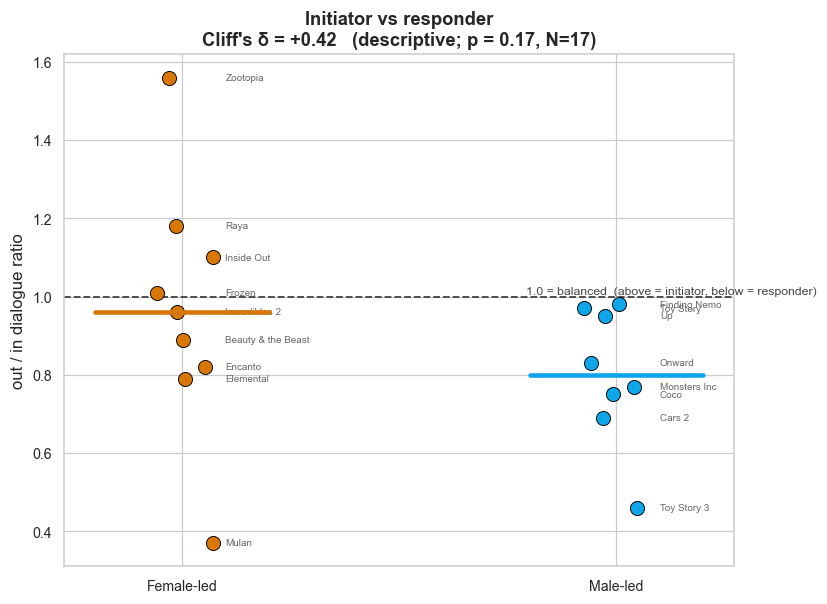

(0.4166666666666667, 0.16717400246812014)

In [3]:
strip_compare('out_in_ratio', 'Initiator vs responder', 'out / in dialogue ratio',
              ref=1.0, ref_label='1.0 = balanced  (above = initiator, below = responder)',
              fname='fig_desc_out_in_ratio')

**Read:** **every male lead (8/8) is a responder** (< 1); **4/9 female leads initiate** (> 1) — Hopps (1.56) most, Mulan (0.37) the most extreme responder. Striking but **underpowered** (could be coin-flip at N=17). Best paper candidate alongside best-friend gender.

### 1.2 ⭐ KEEP — best-friend gender
The alter the protagonist addresses most, and its gender.

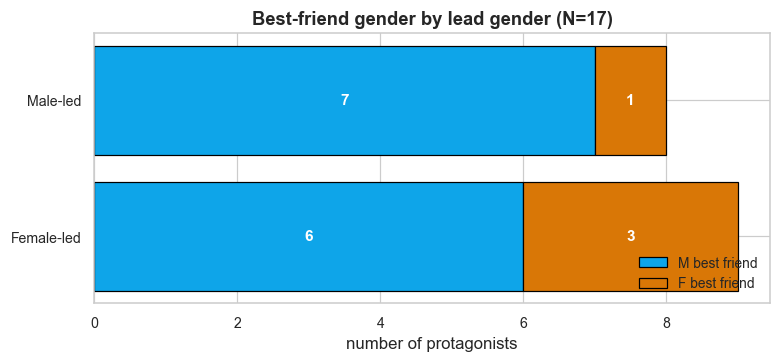

               film_title protagonist lead_gender best_friend bf_gender  bf_ratio_pct  bf_reciprocity
Beauty & the Beast (1991)       Belle           F       Beast         M          28.6            0.98
             Mulan (1998)       Mulan           F       Shang         M          22.5            1.19
            Frozen (2013)        Anna           F    Kristoff         M          30.7            1.02
        Inside Out (2015)         Joy           F     Sadness         F          30.1            0.80
          Zootopia (2016)       Hopps           F        Nick         M          40.7            0.55
     Incredibles 2 (2018)  Elastigirl           F      Evelyn         F          27.0            1.20
           Encanto (2021)     Mirabel           F   Tio Bruno         M          15.5            1.15
              Raya (2021)        Raya           F        Sisu         F          38.7            0.61
         Elemental (2023)       Ember           F        Wade         M          3

In [4]:
bf = df.dropna(subset=['bf_gender']).copy()
ct = bf.groupby(['lead_gender','bf_gender']).size().unstack(fill_value=0).reindex(GENDER_ORDER)
fig, ax = plt.subplots(figsize=(7.2,3.4))
left = np.zeros(len(ct))
for bg, c in [('M', GENDER_PALETTE['M']), ('F', GENDER_PALETTE['F'])]:
    vals = ct.get(bg, pd.Series([0]*len(ct), index=ct.index)).values
    ax.barh(range(len(ct)), vals, left=left, color=c, edgecolor='black', label=f'{bg} best friend')
    for i,v in enumerate(vals):
        if v>0: ax.text(left[i]+v/2, i, str(int(v)), va='center', ha='center', color='white', weight='bold')
    left += vals
ax.set_yticks(range(len(ct))); ax.set_yticklabels(['Female-led','Male-led'])
ax.set_xlabel('number of protagonists'); ax.set_title("Best-friend gender by lead gender (N=17)")
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout(); fig.savefig(FIG/'fig_desc_bf_gender.png', dpi=150); fig.savefig(FIG/'fig_desc_bf_gender.pdf'); plt.show()
print(bf[['film_title','protagonist','lead_gender','best_friend','bf_gender','bf_ratio_pct','bf_reciprocity']].to_string(index=False))

**Read:** **13/17 leads have a male best friend.** Among male leads it is **7/8** (the *only* male lead with a female best friend is **Marlin → Dory**); among female leads **6/9**. A clean corpus fact. `bf_ratio_pct` (concentration) and `bf_reciprocity` are **🔸 DEMOTE** — descriptive only (printed above).

### 1.3 🔸 DEMOTE — `pct_addressed_by_male` (whose world is the lead in?)
Share of lines **directed at** the protagonist that come from male speakers. **Caveat: raw — cast-confounded** (a male-heavy cast inflates this), the same confound H1 corrects for. Read as colour, not as a behaviour claim.

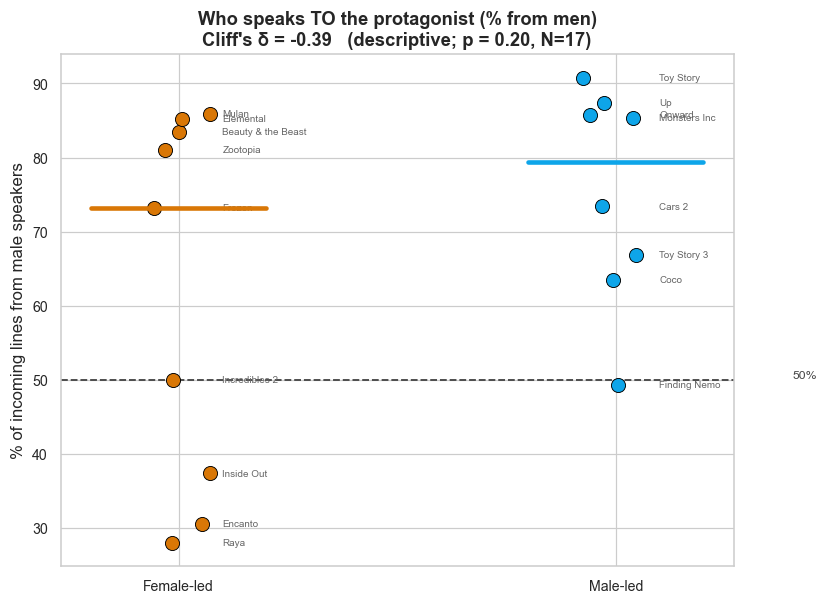

(-0.3888888888888889, 0.1995886466474702)

In [5]:
strip_compare('pct_addressed_by_male', 'Who speaks TO the protagonist (% from men)', '% of incoming lines from male speakers',
              ref=50, ref_label='50%', fname='fig_desc_pct_addressed_by_male')

**Read:** female leads span a much wider range (Raya 28% → Mulan 86%) than male leads — "there is no single female social world." But this is **raw**; the cast-adjusted version of this idea is H1 itself.

### 1.4 ⛔ DROP — `isolation_pct` (monologue + non-human addressing)
Share of the protagonist's lines spoken to themselves or to non-character entities.

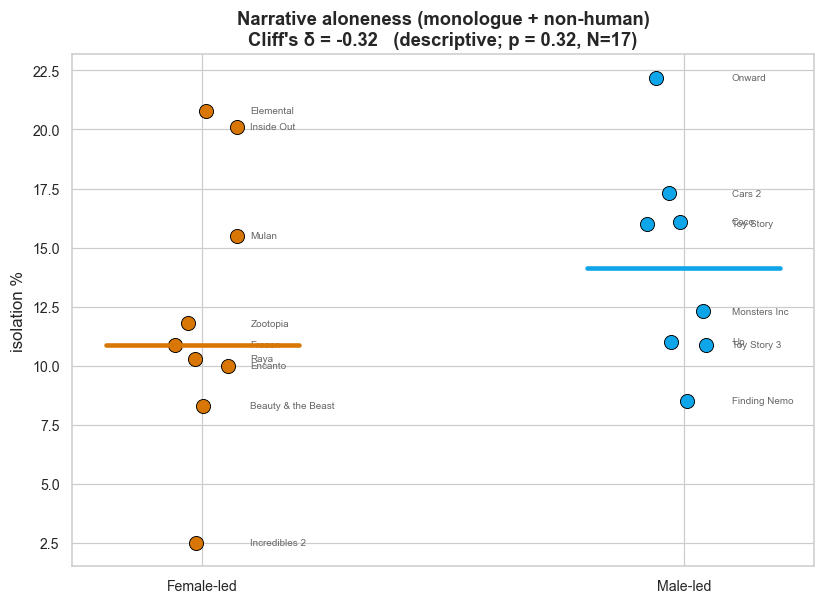

(-0.3194444444444444, 0.3212669683257919)

In [6]:
strip_compare('isolation_pct', 'Narrative aloneness (monologue + non-human)', 'isolation %', fname='fig_desc_isolation')

**Read:** medians overlap (F 10.9% vs M 14.1%), top films cross gender (Ian, Ember, Joy). **No gender story — drop as a finding.**

## 2. Structural extensions (Sonia's H2 / H3)

### 2.1 🔸 DEMOTE — `female_alter_betw_z` (are the lead's female alters structurally important?)
Mean betweenness z-score of the protagonist's **female** alters. > 0 = they punch above chance structurally.

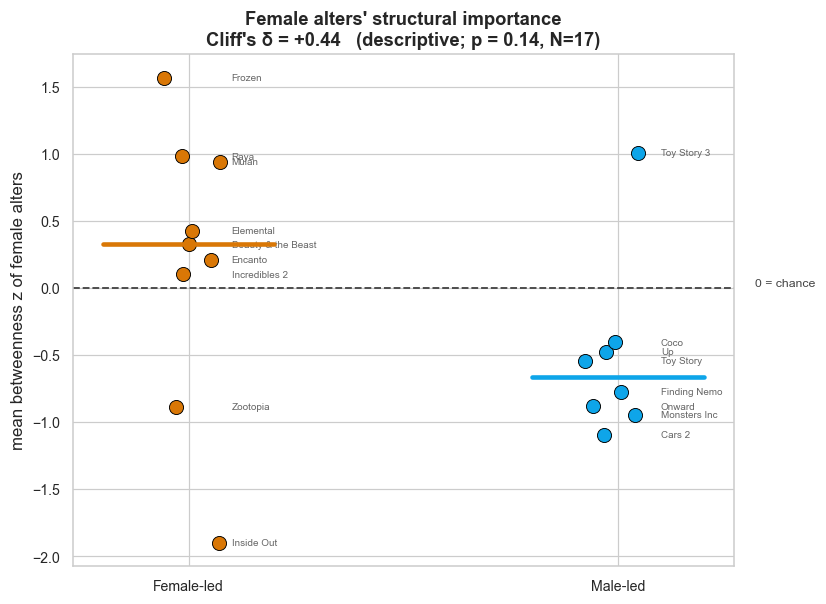

(0.4444444444444444, 0.13879062114356233)

In [7]:
strip_compare('female_alter_betw_z', "Female alters' structural importance", 'mean betweenness z of female alters',
              ref=0, ref_label='0 = chance', fname='fig_desc_female_alter_betw_z')

**Read:** direction is interesting — female alters in F-led films sit higher (δ = +0.44), led by Frozen (+1.57); but it is **not significant** and driven by 2–3 films. Descriptive only.

### 2.2 ⛔ DROP — `burt_constraint` & `ego_density` (confounded)
`burt_constraint` is **not null-adjusted** (raw Burt 1992). `ego_density` is **confounded with network size** (smaller casts → denser ego-nets trivially). Shown together, do not claim.

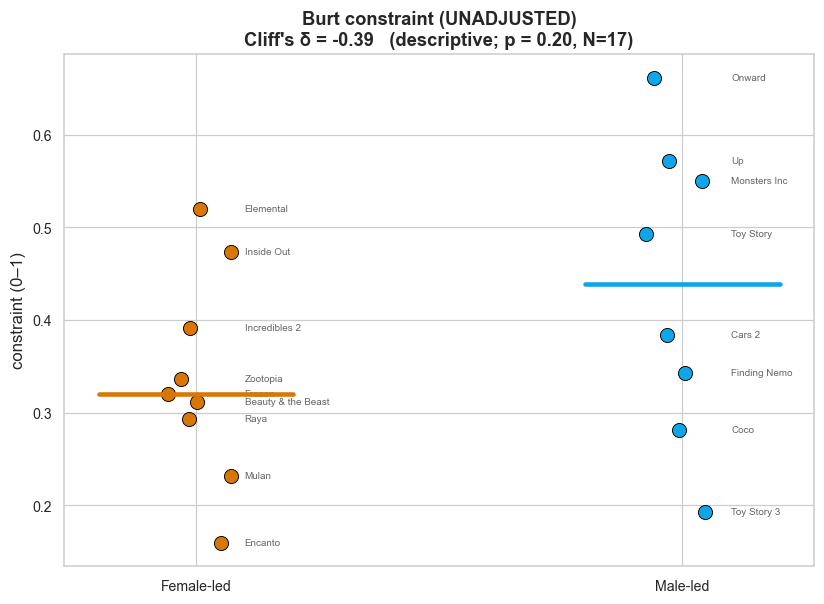

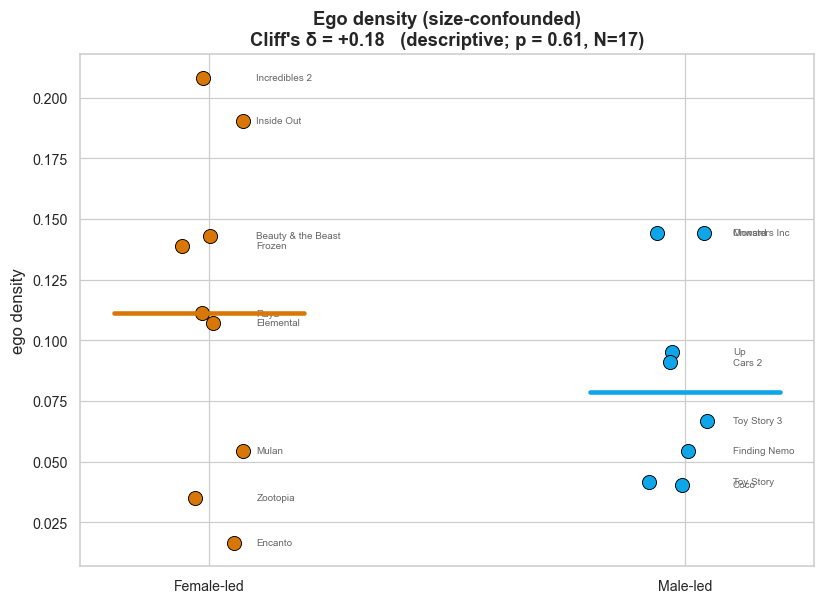

In [8]:
for col, t, yl, fn in [('burt_constraint','Burt constraint (UNADJUSTED)','constraint (0–1)','fig_desc_burt'),
                        ('ego_density','Ego density (size-confounded)','ego density','fig_desc_ego_density')]:
    strip_compare(col, t, yl, fname=fn)

## 4. ⛔ DROP block — checked, null or confounded (no individual figures)

In [10]:
drop_cols = {
    'alter_conflict_exposure':'alters↔antagonist dialogue (LOW_CONF-dependent)',
    'antagonist_betweenness_z':'villain centrality z (Mulan NaN; messy)',
    'reciprocity':'film-level reciprocity (null)',
    'protag_betweenness':'protagonist betweenness raw (underpowered null)',
    'mean_clustering':'global clustering (null)',
    'density':'global density (null)',
}
rows=[]
for c, why in drop_cols.items():
    s=df.dropna(subset=[c]); F=s[s.lead_gender=='F'][c].values; M=s[s.lead_gender=='M'][c].values
    if len(F)<2 or len(M)<2: continue
    rows.append({'metric':c, 'F_median':round(np.median(F),3), 'M_median':round(np.median(M),3),
                 'Cliffs_delta':round(cliffs_delta(F,M),3), 'MW_p':round(mannwhitney(F,M)['p'],3),
                 'verdict':'DROP', 'why':why})
pd.DataFrame(rows)

,metric,F_median,M_median,Cliffs_delta,MW_p,verdict,why
0,alter_conflict_exposure,0.048,0.122,-0.266,0.442,DROP,alters↔antagonist dialogue (LOW_CONF-dependent)
1,antagonist_betweenness_z,-0.310,0.253,-0.107,0.779,DROP,villain centrality z (Mulan NaN; messy)
2,reciprocity,0.704,0.696,-0.069,0.888,DROP,film-level reciprocity (null)
3,protag_betweenness,0.403,0.433,0.028,0.963,DROP,protagonist betweenness raw (underpowered null)
4,mean_clustering,0.291,0.284,-0.028,0.963,DROP,global clustering (null)
5,density,0.173,0.105,0.361,0.236,DROP,global density (null)


## 5. Summary — every metric with its verdict

In [11]:
VERDICT = {
 'out_in_ratio':'⭐ KEEP', 'bf_gender(cat)':'⭐ KEEP',
 'pct_addressed_by_male':'🔸 DEMOTE', 'female_alter_betw_z':'🔸 DEMOTE',
 'bf_ratio_pct':'🔸 DEMOTE', 'bf_reciprocity':'🔸 DEMOTE', 'conflict_dialogue_ratio':'🔸 FRAGILE',
 'isolation_pct':'⛔ DROP', 'burt_constraint':'⛔ DROP', 'ego_density':'⛔ DROP',
 'alter_conflict_exposure':'⛔ DROP', 'antagonist_betweenness_z':'⛔ DROP', 'reciprocity':'⛔ DROP',
}
rows=[]
for c,v in VERDICT.items():
    if c.endswith('(cat)'): 
        rows.append({'metric':c,'F_median':'—','M_median':'—','Cliffs_delta':'—','MW_p':'—','verdict':v}); continue
    s=df.dropna(subset=[c]); F=s[s.lead_gender=='F'][c].values; M=s[s.lead_gender=='M'][c].values
    rows.append({'metric':c,'F_median':round(np.median(F),3),'M_median':round(np.median(M),3),
                 'Cliffs_delta':round(cliffs_delta(F,M),3),'MW_p':round(mannwhitney(F,M)['p'],3),'verdict':v})
summary=pd.DataFrame(rows); summary.to_csv(FIG.parent/'tables_n17'/'desc_metric_verdicts.csv', index=False)
summary

,metric,F_median,M_median,Cliffs_delta,MW_p,verdict
0,out_in_ratio,0.96,0.8,0.417,0.167,⭐ KEEP
1,bf_gender(cat),—,—,—,—,⭐ KEEP
2,pct_addressed_by_male,73.2,79.4,-0.389,0.2,🔸 DEMOTE
3,female_alter_betw_z,0.325,-0.661,0.444,0.139,🔸 DEMOTE
4,bf_ratio_pct,30.1,28.4,0.0,1.0,🔸 DEMOTE
5,bf_reciprocity,1.02,1.085,-0.25,0.423,🔸 DEMOTE
6,conflict_dialogue_ratio,0.17,0.043,0.594,0.05,🔸 FRAGILE
7,isolation_pct,10.9,14.15,-0.319,0.321,⛔ DROP
8,burt_constraint,0.32,0.438,-0.389,0.2,⛔ DROP
9,ego_density,0.111,0.079,0.181,0.606,⛔ DROP


## Takeaway
- **Promotable to the paper (a short paragraph each, if at all):** `out_in_ratio` (8/8 male leads are responders) and **best-friend gender** (13/17 male best friends; only Marlin has a female one). Both are clean, legible **descriptions** — frame as descriptive, never as confirmed effects.
- **Everything else** is descriptive colour or confounded/underpowered → keep here as a record, leave it out of the paper (matching DRAFT v2's Appendix-D decision).
- This notebook **does not overturn** that editorial filter — it visualises the full set so the nulls are visible, with each metric's verdict attached.

> Exploratory record only. Figures: `analysis/h1_homophily/figures_n17/fig_desc_*`. Verdict table: `tables_n17/desc_metric_verdicts.csv`.